In [1]:
import jax.numpy as jnp
import jax 
import matplotlib.pyplot as plt
import diffrax

from algorithms.nuts import nuts
from utilities.helpers import effective_sample_size,autocorr_new

jax.config.update('jax_platform_name', 'cpu')

print(jax.devices())



An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[CpuDevice(id=0)]


In [2]:
def s(k, K):
    """A non-dimension coordinate from -1..+1 corresponding to k=0..K"""
    return 2 * (0.5 + k) / K - 1

In [3]:
K = 5  # Number of globa-scale variables X
J = 3  # Number of local-scale Y variables per single global-scale X variable
nt = 5  # Number of time steps
si = 0.005  # Sampling time interval
dt = 0.005  # Time step
F = 10.0  # Focring
h = jnp.log(8/10)  # Coupling coefficient
b = jnp.log(1/10.0)  # ratio of amplitudes
c = jnp.log(1/10.0)  # time-scale ratio
k = jnp.arange(K)  # For coordinate in plots
j = jnp.arange(J * K)  # For coordinate in plots

# Initial conditions
X_init = s(k, K) * (s(k, K) - 1) * (s(k, K) + 1)
Y_init = 0 * s(j, J * K) * (s(j, J * K) - 1) * (s(j, J * K) + 1)

In [4]:
def L96_2t_xdot_ydot(t, state, par):
    X,Y = state
    F, h,b,c  = par
    h = 1/jnp.exp(h)
    b = 1/jnp.exp(b)
    c = 1/jnp.exp(c)
    """
    Calculate the time rate of change for the X and Y variables for the Lorenz '96, two time-scale
    model, equations 2 and 3:
        d/dt X[k] =     -X[k-1] ( X[k-2] - X[k+1] )   - X[k] + F - h.c/b sum_j Y[j,k]
        d/dt Y[j] = -b c Y[j+1] ( Y[j+2] - Y[j-1] ) - c Y[j]     + h.c/b X[k]

    Args:
        X : Values of X variables at the current time step
        Y : Values of Y variables at the current time step
        F : Forcing term
        h : coupling coefficient
        b : ratio of amplitudes
        c : time-scale ratio
    Returns:
        dXdt, dYdt, C : Arrays of X and Y time tendencies, and the coupling term -hc/b*sum(Y,j)
    """

    JK, K = len(Y), len(X)
    J = JK // K
    # assert JK == J * K, "X and Y have incompatible shapes"
    Xdot = jnp.zeros(K)
    hcb = (h * c) / b

    Ysummed = Y.reshape((K, J)).sum(axis=-1)

    Xdot = jnp.roll(X, 1) * (jnp.roll(X, -1) - jnp.roll(X, 2)) - X + F - hcb * Ysummed
    Ydot = (
        -c * b * jnp.roll(Y, -1) * (jnp.roll(Y, -2) - jnp.roll(Y, 1))
        - c * Y
        + hcb * jnp.repeat(X, J)
    )

    return (Xdot, Ydot)

In [5]:
def model(ts, y0, par):
    terms = diffrax.ODETerm(L96_2t_xdot_ydot)
    solution = diffrax.diffeqsolve(
        terms,
        diffrax.Dopri8(),
        t0=ts[0],
        t1=ts[-1],
        dt0=0.005,
        y0=y0,
        args=par,
        saveat=diffrax.SaveAt(ts=ts),
        max_steps = 10_000,
    )
    return solution.ys


In [6]:
t = jnp.arange(0, nt + dt, dt)
y0 = (X_init, Y_init)

par = (F, h, b, c)

X, Y = model(t, y0, par)


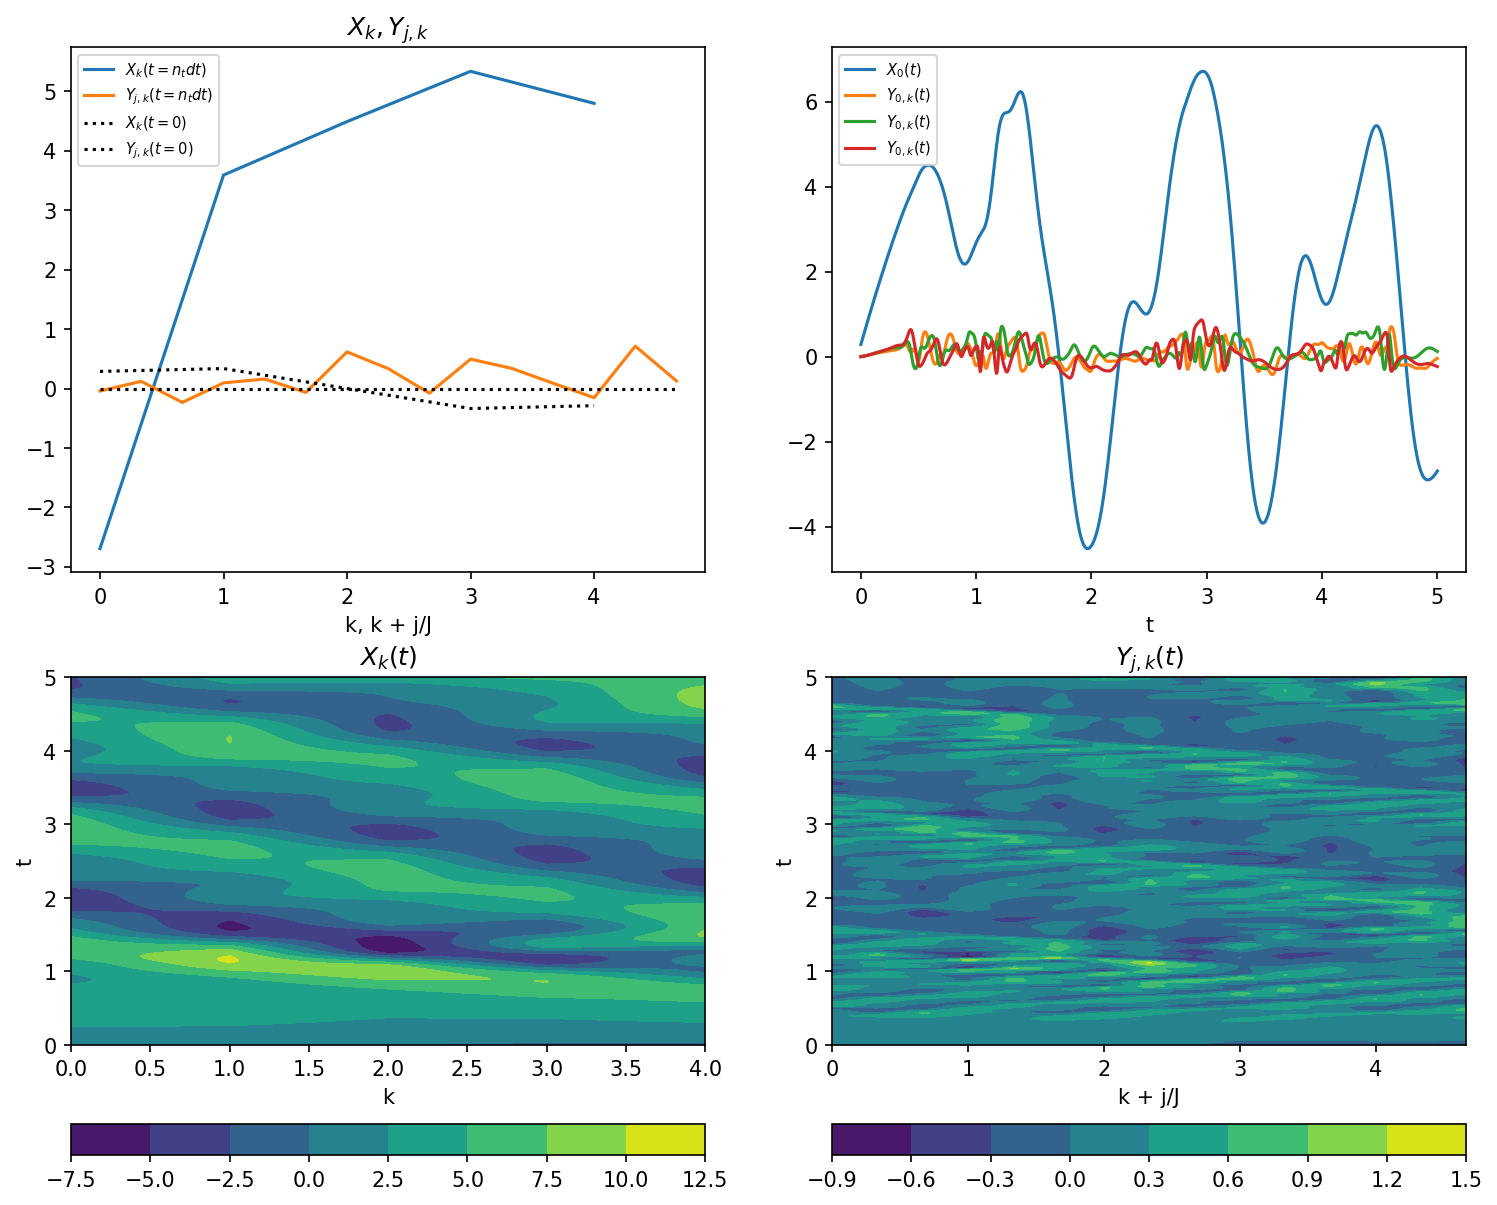

In [7]:
plt.figure(figsize=(12, 10), dpi=150)
plt.subplot(221)

# Snapshot of X[k]
plt.plot(k, X[-1], label="$X_k(t=n_t dt)$")
plt.plot(j / J, Y[-1], label="$Y_{j,k}(t=n_t dt)$")
plt.plot(k, X_init, "k:", label="$X_k(t=0)$")
plt.plot(j / J, Y_init, "k:", label="$Y_{j,k}(t=0)$")
plt.legend(fontsize=7)
plt.xlabel("k, k + j/J")
plt.title("$X_k, Y_{j,k}$")
plt.subplot(222)

# Sample time-series X[0](t), Y[0](t)
plt.plot(t, X[:, 0], label="$X_0(t)$")
plt.plot(t, Y.reshape((len(t), K, J))[:, 0, :], label="$Y_{0,k}(t)$")
plt.legend(fontsize=7)
plt.xlabel("t")
plt.subplot(223)

# Full model history of X
plt.contourf(k, t, X)
plt.colorbar(orientation="horizontal")
plt.xlabel("k")
plt.ylabel("t")
plt.title("$X_k(t)$")
plt.subplot(224)

# Full model history of Y
plt.contourf(j / J, t, Y)
plt.colorbar(orientation="horizontal")
plt.xlabel("k + j/J")
plt.ylabel("t")
plt.title("$Y_{j,k}(t)$");

In [8]:
observations =  X 

cov = jnp.eye(K)

def log_likelihood(par):
    model_output,_ = model(t,y0,(F,*par))
    return jnp.sum(
        jax.scipy.stats.multivariate_normal.logpdf(
            observations,
            model_output,
            cov
        )
    )

In [9]:
func = jax.jit(jax.value_and_grad(log_likelihood))

D = 3
M = 5000
Madapt = 1000
num_chains = 1
key = jax.random.key(0)
init_key, key = jax.random.split(key)

nuts_key, key = jax.random.split(key)
samples, lnprob = nuts(
    func,
    M,
    Madapt,
    jnp.log(jnp.array([0.7,0.15,0.15])),
    key=nuts_key,
    epsilon=0.0000000002,
    num_chains=num_chains,
)

print(f"Effective sample size: {effective_sample_size(samples)}")
print(f"Integrated autocorrelation: {autocorr_new(samples)}")

KeyboardInterrupt: 

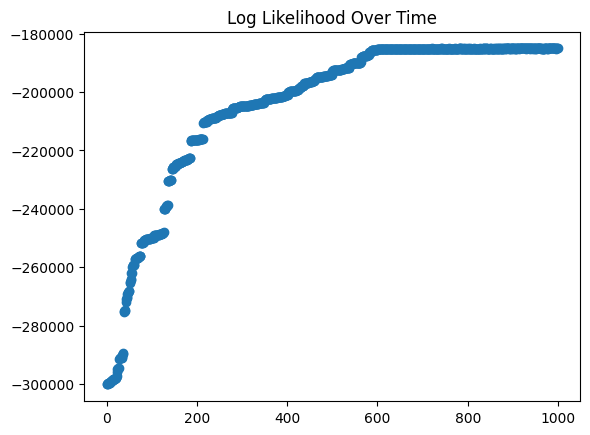

In [ ]:
plt.title('Log Likelihood Over Time')
plt.scatter(jnp.arange(0,M),lnprob)
plt.show()

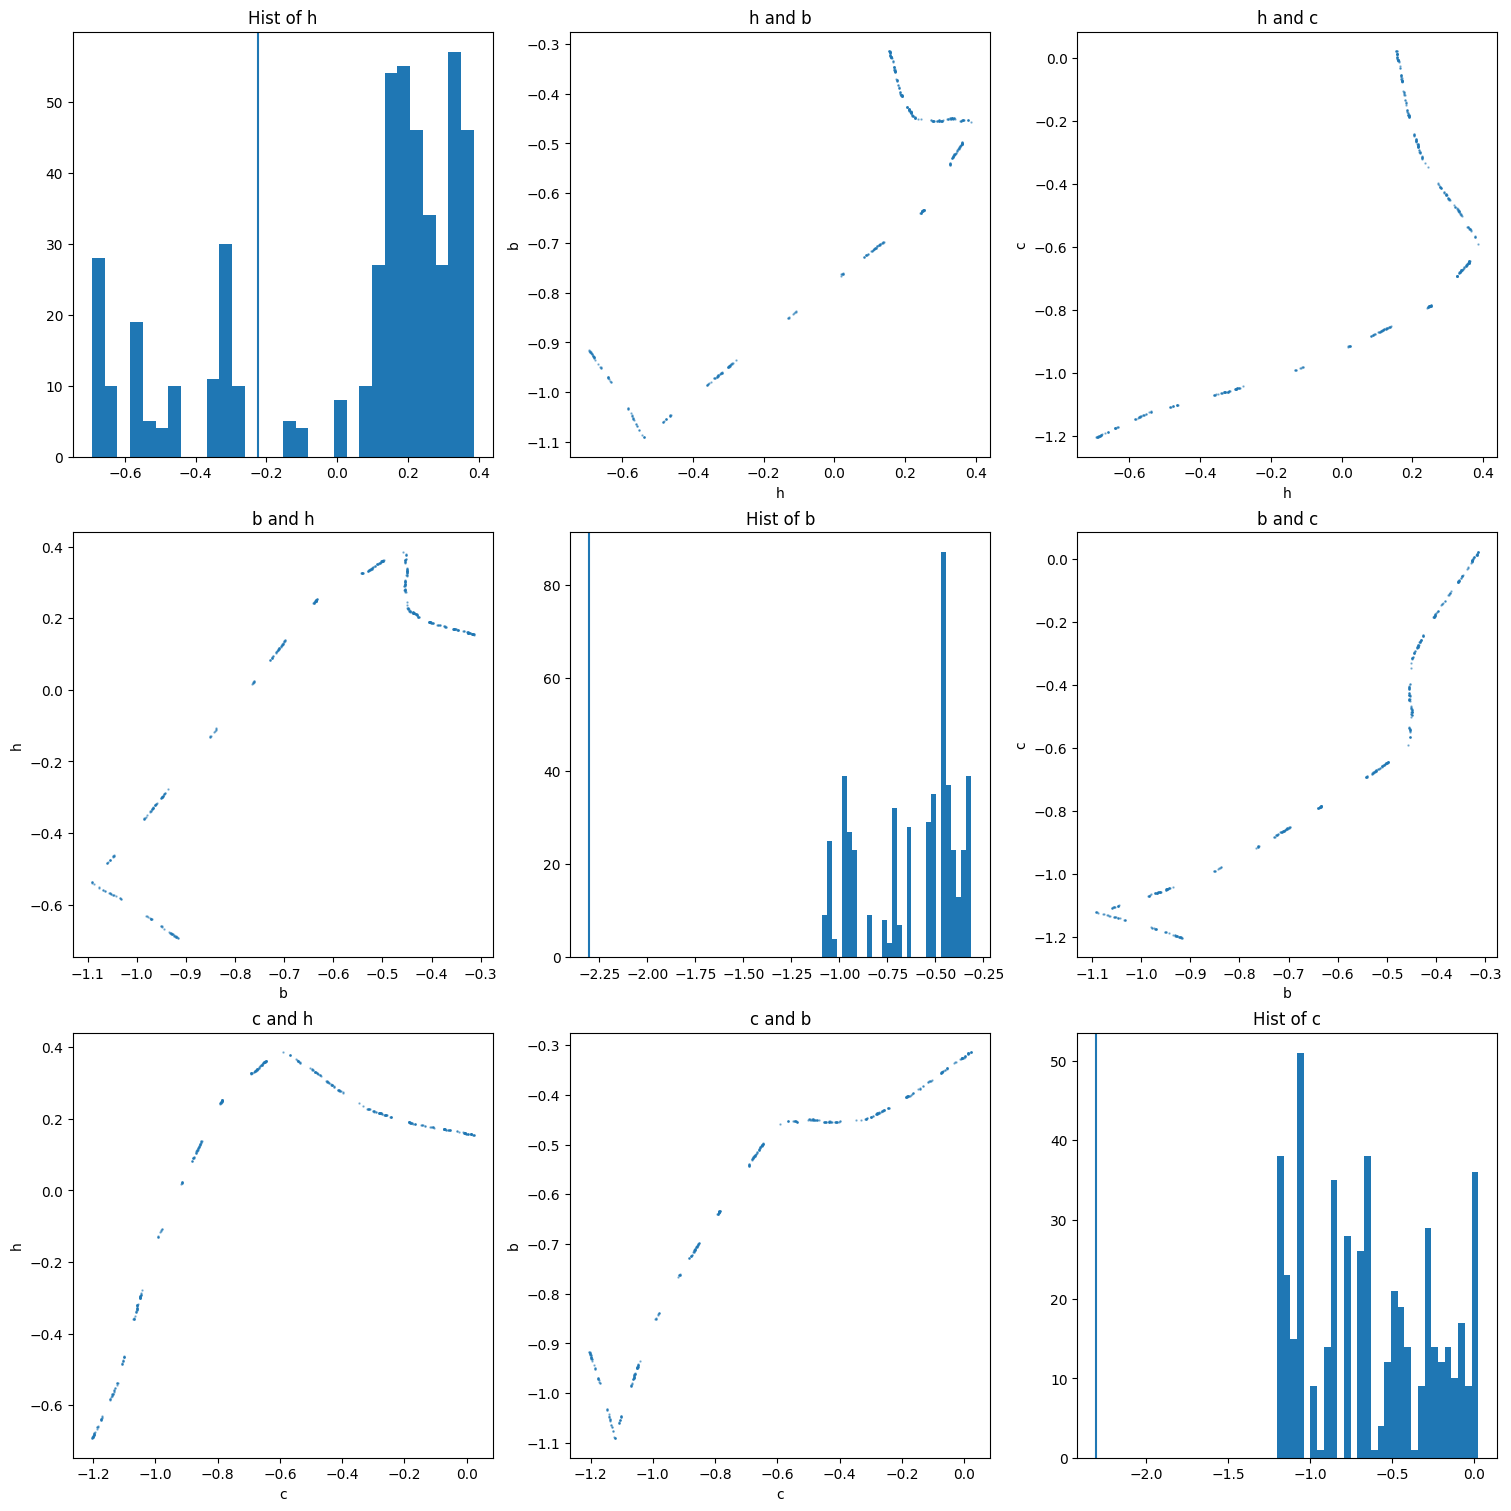

In [ ]:
fig, axes = plt.subplots(D, D, figsize=(15, 15), layout="constrained") # adjusted size for visibility
par_names = ["h", "b", "c"]
true_params = [h,b,c]

samples = samples.squeeze()

for par1_index in range(D):
    for par2_index in range(D):
        if par1_index != par2_index: 
            axes[par1_index, par2_index].set_title(
                f"{par_names[par1_index]} and {par_names[par2_index]}"
            )
            # Corrected indexing here: [:, index]
            axes[par1_index, par2_index].scatter(
                samples[:, par1_index],
                samples[:, par2_index],
                s=0.5,
                alpha=0.5
            )
            axes[par1_index, par2_index].set_xlabel(f"{par_names[par1_index]}")
            axes[par1_index, par2_index].set_ylabel(f"{par_names[par2_index]}")
        else:
            # Optional: Plot histograms on the diagonal!
            axes[par1_index, par2_index].hist(samples[:, par1_index], bins=30)
            axes[par1_index, par2_index].set_title(f"Hist of {par_names[par1_index]}")
            axes[par1_index,par2_index].axvline(true_params[par1_index])

plt.show()